# 01 — Análise Exploratória de Dados

**Dimensão 3 da rúbrica — 20 pontos.**

Toda visualização precisa de um parágrafo de interpretação logo abaixo.
Gráfico sem leitura perde metade dos pontos do critério.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Semente fixa.
RANDOM_STATE = 42

# Caminhos dos arquivos com base na estrutura do projeto
RAW_APP = Path("../data/raw/application_record.csv")
RAW_CREDIT = Path("../data/raw/credit_record.csv")

# A variável alvo será construída no notebook 02, mas deixamos o nome configurado
TARGET = "target"

# Configuração para mostrar todas as colunas
pd.set_option("display.max_columns", None)

**Explicação do código:** Importamos as bibliotecas necessárias (`pandas` para manipulação de dados, `matplotlib` e `seaborn` para gráficos) e a biblioteca `Path` para lidar com caminhos de arquivos de forma compatível com qualquer sistema operacional. 
Definimos o `RANDOM_STATE = 42` para reprodutibilidade, mapeamos os caminhos dos arquivos que serão usados no projeto, que estão na pasta `data/raw/` e na última linha de código, configuramos o Pandas para não ocultar colunas ao exibir os DataFrames.

In [2]:
# Carregando os datasets. Salvando as informações de cada dataset em variáveis distintas
df_aplication = pd.read_csv(RAW_APP)
df_credit = pd.read_csv(RAW_CREDIT)

# Exibindo as primeiras linhas de cada Dataset
print("=== Application Record ===")
display(df_aplication.head())

print("\n=== Credit Record ===")
display(df_credit.head())

=== Application Record ===


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0



=== Credit Record ===


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


**Explicação do código:** Carregamos os dois arquivos CSV para a memória em DataFrames distintos (`df_aplication` e `df_credit`). A função `display()` combinada com `.head()` exibe as primeiras 5 linhas de cada tabela, permitindo uma inspeção visual cruzada das estruturas de perfil demográfico e de histórico financeiro.

In [3]:
print("======= Visão Geral: Application Record =======")
print(f"Dimensões: {df_aplication.shape}\n")
df_aplication.info()
# O .style.format("{:.2f}") remove a notação científica e fixa 2 casas decimais
display(df_aplication.describe().T.style.format("{:.2f}"))

print("\n" + "="*50 + "\n")

print("======= Visão Geral: Credit Record =======")
print(f"Dimensões: {df_credit.shape}\n")
df_credit.info()
display(df_credit.describe().T.style.format("{:.2f}"))

======= Visão Geral: Application Record =======
Dimensões: (438557, 18)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  


,count,mean,std,min,25%,50%,75%,max
ID,438557.00,6022176.27,571637.02,5008804.00,5609375.00,6047745.00,6456971.00,7999952.00
CNT_CHILDREN,438557.00,0.43,0.72,0.00,0.00,0.00,1.00,19.00
AMT_INCOME_TOTAL,438557.00,187524.29,110086.85,26100.00,121500.00,160780.50,225000.00,6750000.00
DAYS_BIRTH,438557.00,-15997.90,4185.03,-25201.00,-19483.00,-15630.00,-12514.00,-7489.00
DAYS_EMPLOYED,438557.00,60563.68,138767.80,-17531.00,-3103.00,-1467.00,-371.00,365243.00
FLAG_MOBIL,438557.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00
FLAG_WORK_PHONE,438557.00,0.21,0.40,0.00,0.00,0.00,0.00,1.00
FLAG_PHONE,438557.00,0.29,0.45,0.00,0.00,0.00,1.00,1.00
FLAG_EMAIL,438557.00,0.11,0.31,0.00,0.00,0.00,0.00,1.00
CNT_FAM_MEMBERS,438557.00,2.19,0.90,1.00,2.00,2.00,3.00,20.00




======= Visão Geral: Credit Record =======
Dimensões: (1048575, 3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


,count,mean,std,min,25%,50%,75%,max
ID,1048575.00,5068286.42,46150.58,5001711.00,5023644.00,5062104.00,5113856.00,5150487.00
MONTHS_BALANCE,1048575.00,-19.14,14.02,-60.00,-29.00,-17.00,-7.00,0.00


**Explicação do código:** Utilizamos `.shape` para extrair o volume de linhas e colunas de cada base. O método `.info()` detalha os tipos de dados e a presença de nulos, enquanto `.describe().T` exibe as estatísticas descritivas básicas.

**Interpretação:** Verificando os dois datasets, observamos que há um campo em comum, o `ID`, que será utilizado para cruzar informações. 
* A base `application_record` possui 438.557 registros e 18 variáveis cadastrais. As métricas temporais (`DAYS_BIRTH` e `DAYS_EMPLOYED`) estão em formato negativo (contagem regressiva de dias) e há um outlier extremo na coluna de emprego `DAY_EMPLOYED` (365243), sugerindo um marcador para desempregados ou pensionistas. 
* A informação do outlier da coluna de emprego `DAY_EMPLOYED`, pode ser observada ao executarmos o comando `df_aplocation.describe().T`, onde consta na coluna max(), o valor de 365243.0. O valor de -17531.0, para esse mesmo campo, equivale a 48 anos de vínculo empregatício, dessa forma, nã é considerado um outlier.
* A base `credit_record` é longitudinal (acompanha o comportamento ao longo do tempo), possuindo mais de 1 milhão de registros (1.048.575) distribuídos em 3 colunas, detalhando o status de pagamento mensal (`STATUS`) por mês de referência (`MONTHS_BALANCE`). 
* Ambas as bases aparentam estar bem preenchidas, sem valores nulos explícitos indicados nas colunas principais nesta primeira contagem do `.info()`.
* Foi usado a função `.style.format()`para ajustar a exibição dos números, usando casas decimais fixas. As casas decimais sõa separadas por ponto ".".
* No trecho de código `{:.2f}` as chaves {}, representa onde cada número será inserido. O ":" é usado pelo python para indicar a regra visual que deve ser aplicada. O ".2" defini a precisão do número, nesse caso, duas casas decimais e o "f" informa que o número deve ser formatado como um número de ponto flutuante. A letra "f" que desativa a notação de número cientíofico (valores como e+06).

## 1. Visão geral

_Dimensões, tipos e primeira impressão do dataset._

In [4]:
print("======= Visão Geral: Application Record =======")
print(f"Dimensões: {df_aplication.shape}\n")
df_aplication.info()
display(df_aplication.describe().T)

print("\n" + "="*50 + "\n")

print("======= Visão Geral: Credit Record =======")
print(f"Dimensões: {df_credit.shape}\n")
df_credit.info()
display(df_credit.describe().T)

======= Visão Geral: Application Record =======
Dimensões: (438557, 18)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  


,count,mean,std,min,25%,50%,75%,max
ID,438557.0,6.022176e+06,571637.023257,5008804.0,5609375.0,6047745.0,6456971.0,7999952.0
CNT_CHILDREN,438557.0,4.273903e-01,0.724882,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,438557.0,1.875243e+05,110086.853066,26100.0,121500.0,160780.5,225000.0,6750000.0
DAYS_BIRTH,438557.0,-1.599790e+04,4185.030007,-25201.0,-19483.0,-15630.0,-12514.0,-7489.0
DAYS_EMPLOYED,438557.0,6.056368e+04,138767.799647,-17531.0,-3103.0,-1467.0,-371.0,365243.0
FLAG_MOBIL,438557.0,1.000000e+00,0.000000,1.0,1.0,1.0,1.0,1.0
FLAG_WORK_PHONE,438557.0,2.061328e-01,0.404527,0.0,0.0,0.0,0.0,1.0
FLAG_PHONE,438557.0,2.877710e-01,0.452724,0.0,0.0,0.0,1.0,1.0
FLAG_EMAIL,438557.0,1.082071e-01,0.310642,0.0,0.0,0.0,0.0,1.0
CNT_FAM_MEMBERS,438557.0,2.194465e+00,0.897207,1.0,2.0,2.0,3.0,20.0




======= Visão Geral: Credit Record =======
Dimensões: (1048575, 3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


,count,mean,std,min,25%,50%,75%,max
ID,1048575.0,5.068286e+06,46150.578505,5001711.0,5023644.0,5062104.0,5113856.0,5150487.0
MONTHS_BALANCE,1048575.0,-1.913700e+01,14.023498,-60.0,-29.0,-17.0,-7.0,0.0


**Explicação do código:** Utilizamos `.shape` para extrair o volume de linhas e colunas de cada base. O método `.info()` detalha os tipos de dados e a presença de nulos, enquanto `.describe().T` exibe as estatísticas descritivas básicas.

**Interpretação:** Verificando os dois datasets, observamos que há um campo em comum, o `ID`, que será utilizado para cruzar informações. 
* A base `application_record` possui 438.557 registros e 18 variáveis cadastrais. As métricas temporais (`DAYS_BIRTH` e `DAYS_EMPLOYED`) estão em formato negativo (contagem regressiva de dias) e há um outlier extremo na coluna de emprego (365243), sugerindo um marcador para desempregados ou pensionistas. 
* A base `credit_record` é longitudinal (acompanha o comportamento ao longo do tempo), possuindo mais de 1 milhão de registros (1.048.575) distribuídos em 3 colunas, detalhando o status de pagamento mensal (`STATUS`) por mês de referência (`MONTHS_BALANCE`). 
* Ambas as bases aparentam estar bem preenchidas, sem valores nulos explícitos indicados nas colunas principais nesta primeira contagem do `.info()`.

In [5]:
# O comando describe por padrão, exibi informações apenas de variáveis numéricas.
# Pde-se observar que no dataset df_aplication há 17 variáveis, mas apenas 10 variáveis aparecem ao ser executado o comando describe()
# Para exibir, incluir as variáveis categóricas, podemos executar o comando abaixo.

# display(df_aplication.describe(include='all').T)

In [6]:
# Exibindo apenas as variáveis categóricas.
display(df_aplication.describe(include=['object']).T)

,count,unique,top,freq
CODE_GENDER,438557,2,F,294440
FLAG_OWN_CAR,438557,2,N,275459
FLAG_OWN_REALTY,438557,2,Y,304074
NAME_INCOME_TYPE,438557,5,Working,226104
NAME_EDUCATION_TYPE,438557,5,Secondary / secondary special,301821
NAME_FAMILY_STATUS,438557,5,Married,299828
NAME_HOUSING_TYPE,438557,6,House / apartment,393831
OCCUPATION_TYPE,304354,18,Laborers,78240


**Explicação do código:** Como o método `.describe()` tradicional ignora colunas de texto por padrão, utilizamos o parâmetro `include=['object']` para forçar o Pandas a analisar exclusivamente as variáveis categóricas da base `df_aplication`. O modificador `.T` (transposição) foi aplicado para inverter linhas e colunas, facilitando a leitura visual.

**Interpretação da Tabela Categórica:**
A análise das colunas textuais revela importantes características demográficas:
* **`count` (Quantidade de registros):** A maioria das colunas possui 438.557 registros preenchidos (o total da base). A única exceção notável é a coluna `OCCUPATION_TYPE` (tipo de ocupação), que possui apenas 304.354 registros preenchidos, indicando a existência de **valores nulos (missing values)** que precisarão ser tratados na etapa de pré-processamento.
* **`unique` (Variedade Distintas):** Variáveis como `CODE_GENDER`, `FLAG_OWN_CAR` e `FLAG_OWN_REALTY` possuem 2 categorias únicas (binárias). Já o tipo de moradia (`NAME_HOUSING_TYPE`) possui 6 variações, e as profissões (`OCCUPATION_TYPE`) totalizam 18 categorias distintas.
* **`top` e `freq` (Tendências):** Observamos perfis predominantes claros na base, como o fato de a maioria dos solicitantes ser do sexo feminino (`F` com 294.440 registros), residir em casa própria ou apartamento (`House / apartment` com quase 394 mil ocorrências) e atuar prioritariamente na categoria de trabalhadores manuais (`Laborers`). Informações que podem ser visualizadas no código acima, gerados pelo `describe()`

## 2. Distribuição das variáveis

**Explicação do código:** A seguir, geramos dois histogramas utilizando a biblioteca `seaborn` para analisar a distribuição financeira e demográfica. Na renda, aplicamos um filtro visual (`< 500000`) para evitar que outliers extremos distorçam o gráfico. Na idade, convertemos a coluna `DAYS_BIRTH` para anos positivos, dividindo por `-365.25`.

A escolha das variáveis demográficas e de capacidade financeira — como idade e renda — bem como a definição da variável alvo baseada no histórico de atrasos, está alinhada às melhores práticas de gestão de risco adotadas pelo Sistema Financeiro Nacional Brasileiro.

Essa seleção é amparada pelas diretrizes de governança e gerenciamento de risco estabelecidas pelo Conselho Monetário Nacional (CMN) e supervisionadas pelo Banco Central do Brasil, especialmente conforme previsto na Resolução CMN nº 2.682/1999, que trata da classificação de operações de crédito segundo o risco, e na Resolução CMN nº 4.557/2017, que dispõe sobre a estrutura de gerenciamento de riscos e capital.

Tais normativos exigem que as instituições utilizem modelos preditivos, informações cadastrais completas e critérios consistentes para mensuração da probabilidade de inadimplência. Nesse contexto, variáveis como renda e idade são amplamente reconhecidas como elementos essenciais para avaliar capacidade de pagamento, comportamento histórico e risco de crédito.

Esse texto é para justificarmos o uso de apenas 02 variáveis na etapa de Distribuição das variáveis.

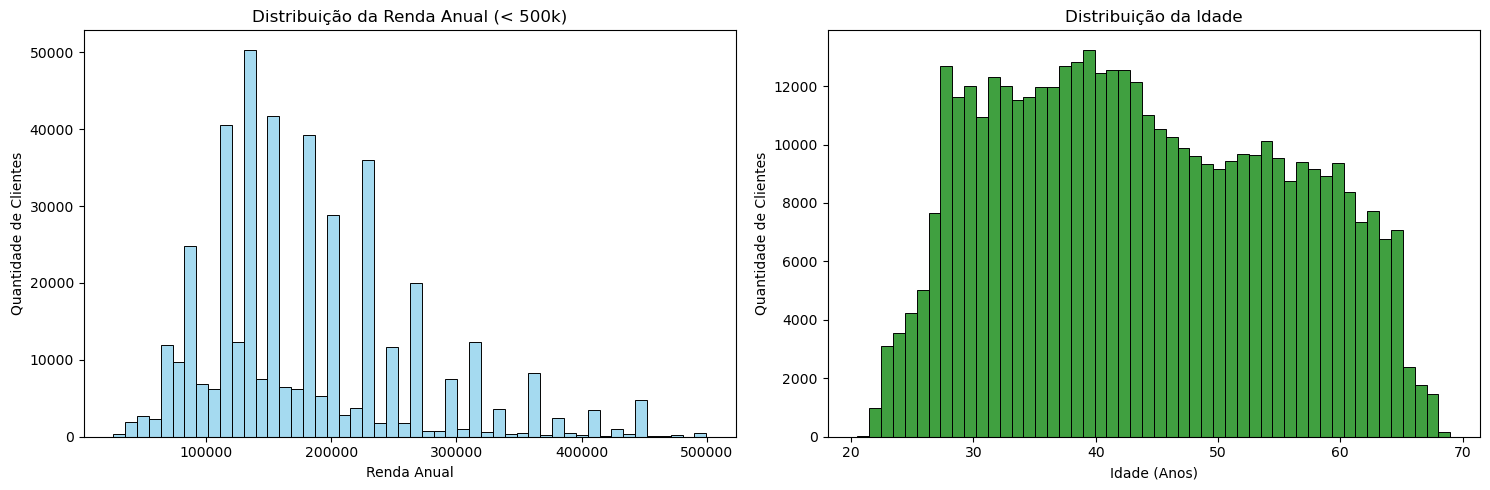

In [7]:
# Variáveis usadas na análise
# renda anual (AMT_INCOME_TOTAL) 
# idade (DAYS_BIRTH)


fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Distribuição da Renda
sns.histplot(df_aplication[df_aplication['AMT_INCOME_TOTAL'] < 500000]['AMT_INCOME_TOTAL'], bins=50, ax=ax[0], color='skyblue')
ax[0].set_title('Distribuição da Renda Anual (< 500k)')
ax[0].set_xlabel('Renda Anual')
ax[0].set_ylabel('Quantidade de Clientes')

# Distribuição da Idade
idades_anos = df_aplication['DAYS_BIRTH'] / -365.25
sns.histplot(idades_anos, bins=50, ax=ax[1], color='green')
ax[1].set_title('Distribuição da Idade')
ax[1].set_xlabel('Idade (Anos)')
ax[1].set_ylabel('Quantidade de Clientes')

plt.tight_layout()
plt.show()

**Interpretação:** A distribuição da renda anual (`AMT_INCOME_TOTAL`) concentra sua grande massa do lado esquerdo do gráfico (entre 100k e 300k). Estatisticamente, isso configura uma **assimetria à direita¹** (right-skewed), pois a cauda da distribuição se estende para a direita para acomodar uma minoria de clientes com rendimentos atipicamente altos. Nota-se também a presença de picos pontuais (ex: próximos a 135k e 225k), sugerindo que os clientes tendem a arredondar os valores informados. Já a distribuição de idade apresenta um **comportamento de planalto²**, com um volume massivo e constante de solicitações de clientes entre os 27 e 45 anos, seguido de um declínio gradual nas faixas etárias mais avançadas.

---
**Notas e Termos Técnicos:**
*   **¹ Assimetria à direita:** Ocorre quando a maior parte dos dados se aglomera no lado esquerdo do gráfico (valores mais comuns), fazendo com que a "cauda" da distribuição se estique para a direita apenas para alcançar poucos valores extremamente altos.
*   **² Comportamento de planalto:** Metáfora visual para descrever um gráfico que, em vez de formar um pico único e agudo (como uma montanha), forma uma área alta, achatada e constante (como uma chapada). Isso indica que não há apenas uma idade isolada que mais solicita crédito, mas sim uma faixa etária inteira com forte estabilidade.

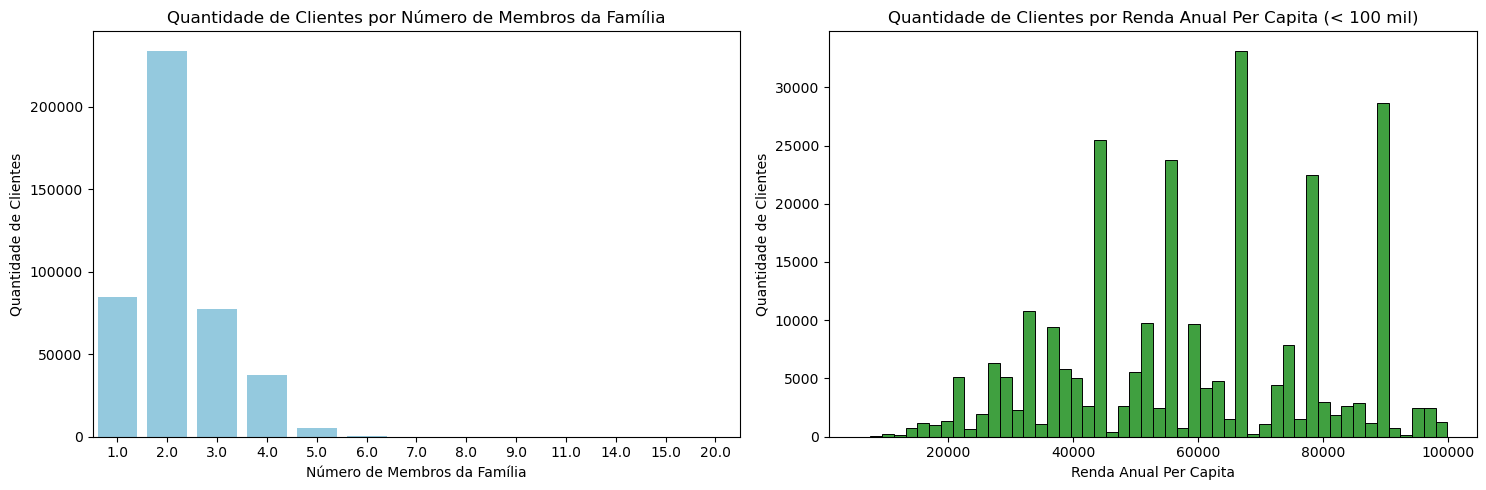

In [8]:
# Variáveis usadas na análise
# Quantidade de membros da família (CNT_FAM_MEMBERS)
# Renda anual total (AMT_INCOME_TOTAL)
# Renda per capita (AMT_INCOME_TOTAL / CNT_FAM_MEMBERS)

# Cálculo da renda per capita
df_aplication['AMT_INCOME_PER_CAPITA'] = (
    df_aplication['AMT_INCOME_TOTAL'] /
    df_aplication['CNT_FAM_MEMBERS']
)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# ============================================================
# 1. Quantidade de clientes por número de membros da família
# ============================================================

sns.countplot(
    data=df_aplication,
    x='CNT_FAM_MEMBERS',
    ax=ax[0],
    color='skyblue'
)

ax[0].set_title(
    'Quantidade de Clientes por Número de Membros da Família'
)
ax[0].set_xlabel('Número de Membros da Família')
ax[0].set_ylabel('Quantidade de Clientes')


# ============================================================
# 2. Quantidade de clientes por faixa de renda per capita
# ============================================================

sns.histplot(
    data=df_aplication[
        df_aplication['AMT_INCOME_PER_CAPITA'] < 100000
    ],
    x='AMT_INCOME_PER_CAPITA',
    bins=50,
    ax=ax[1],
    color='green'
)

ax[1].set_title(
    'Quantidade de Clientes por Renda Anual Per Capita (< 100 mil)'
)
ax[1].set_xlabel('Renda Anual Per Capita')
ax[1].set_ylabel('Quantidade de Clientes')


# Ajuste do espaçamento
plt.tight_layout()

# Exibição dos gráficos
plt.show()

## 3. Correlações

**Fundamentação Conceitual e Estatística:**
Antes de interpretarmos o mapa de calor (*heatmap*), é fundamental estabelecer três premissas metodológicas essenciais para a análise de dados:
1. **O que é Correlação:** Trata-se de uma medida estatística (neste caso, o coeficiente de Pearson) que quantifica a força e a direção da relação linear entre duas variáveis. Os valores variam de $-1$ a $1$, onde valores próximos de $1$ indicam que as variáveis crescem juntas (correlação positiva), valores próximos de $-1$ indicam que quando uma cresce a outra diminui (correlação negativa), e valores próximos de $0$ indicam ausência de relação linear.
2. **Correlação não implica Causa:** Um dos erros mais comuns na análise de dados é assumir causalidade baseando-se apenas em correlações estatísticas. O facto de duas variáveis variarem em conjunto não significa que uma seja a causa direta da outra; essa situação pode ocorrer quando ambas são influenciadas por um terceiro fator oculto ou por características estruturais da base.
3. **Tipos de Variáveis Utilizadas:** O cálculo de correlação linear exige obrigatoriamente **variáveis quantitativas (numéricas)**, que podem ser contínuas (como a renda e a idade) ou discretas (como o número de filhos). Variáveis qualitativas (categóricas/texto) não entram diretamente nesta matriz. Por esse motivo, filtramos apenas os tipos `int64` e `float64`, descartando identificadores unívocos e colunas sem variância (`FLAG_MOBIL`).

**Explicação do código:** O script a seguir filtra o *dataset* selecionando apenas as variáveis numéricas válidas, calcula a matriz de correlação de Pearson e plota a visualização gráfica em forma de mapa de calor (*heatmap*) com a biblioteca `seaborn`.

**Identificadores unívocos** são geralmente códigos ou atributos que servem apenas para identificar um registo ou linha individualmente. Funcionam como o campo chave de uma tabela que utiliza números sequenciais para cada novo elemento adicionado à base.

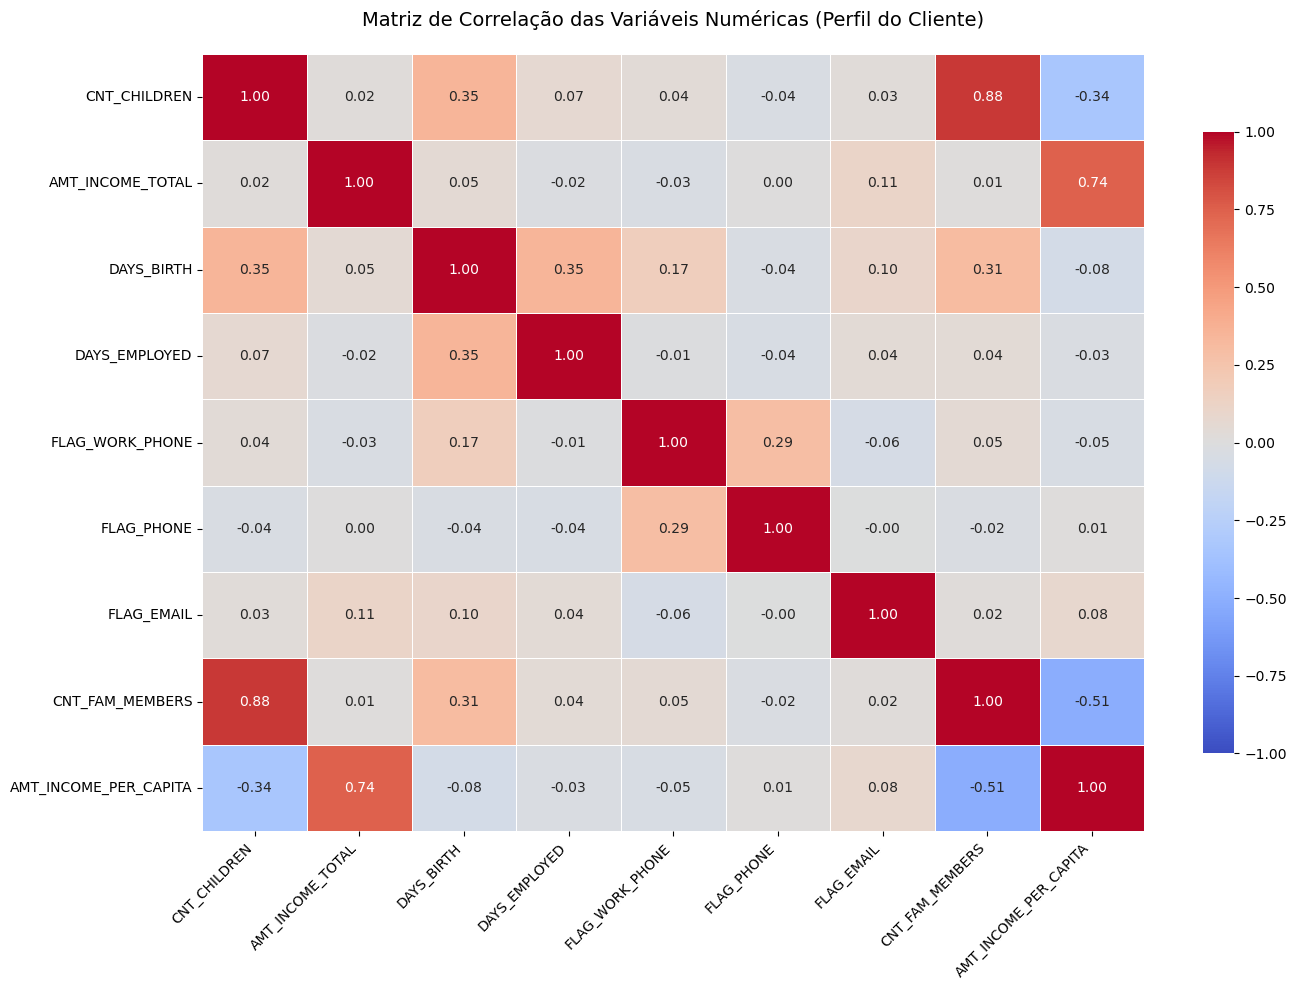

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cria uma cópia do DataFrame para realizar o tratamento do valor sentinela 
# sem modificar o conjunto de dados original de forma prematura
df_corr = df_aplication.copy()

# Substitui o valor sentinela 365243 (utilizado para pensionistas ou desempregados) 
# por NaN para evitar distorções matemáticas no cálculo da correlação linear
df_corr['DAYS_EMPLOYED'] = df_corr['DAYS_EMPLOYED'].replace(365243, np.nan)

# Seleciona as colunas numéricas e descarta identificadores e colunas de variância zero
colunas_numericas = df_corr.select_dtypes(include=['int64', 'float64']).columns
colunas_numericas = colunas_numericas.drop(['ID', 'FLAG_MOBIL'])

# Calcula a matriz de correlação para as variáveis numéricas selecionadas
matriz_correlacao = df_corr[colunas_numericas].corr()

# Configura e plota o mapa de calor (Heatmap) da matriz de correlação
plt.figure(figsize=(14, 10))
sns.heatmap(matriz_correlacao, 
            annot=True, 
            fmt=".2f", 
            cmap="coolwarm", 
            vmin=-1, 
            vmax=1, 
            linewidths=0.5,
            cbar_kws={"shrink": .8})

plt.title('Matriz de Correlação das Variáveis Numéricas (Perfil do Cliente)', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Interpretação:** Analisando as interações no mapa de calor, destacam-se os seguintes pontos de negócio e de estrutura de dados:

1. **Multicolinearidade (`CNT_CHILDREN` [quantidade de filhos] e `CNT_FAM_MEMBERS` [tamanho do grupo familiar]):** Existe uma correlação fortíssima e positiva de 0.88 entre o número de filhos e o tamanho do grupo familiar. Isto é estruturalmente lógico, mas cria redundância matemática. Na fase de modelação, será recomendável manter apenas uma destas variáveis para não enviesar o modelo.
2. **Variância Zero (`FLAG_MOBIL` [indicador de posse de celular/telemóvel]):** A variável de posse de celular foi excluída da matriz de correlação. Como 100% dos clientes na base possuem o dispositivo, a variância é nula, impossibilitando o cálculo de correlação de Pearson. Por não ter capacidade de diferenciação, esta coluna também poderá ser descartada definitivamente na etapa de pré-processamento.
3. **Relação Idade vs. Emprego:** Após o tratamento adequado do valor sentinela (atribuído a desempregados e pensionistas) na variável `DAYS_EMPLOYED`, observa-se uma correlação positiva moderada (aproximadamente +0.35) entre `DAYS_BIRTH` [dias desde o nascimento / idade] e `DAYS_EMPLOYED` [tempo de emprego]. Esse resultado reflete um padrão coerente de mercado, indicando que clientes com maior idade tendem a apresentar históricos de emprego mais consolidados.
4. **Independência da Renda:** A variável `AMT_INCOME_TOTAL` [renda anual total] apresenta interações lineares irrelevantes com os fatores demográficos. Isto sugere que níveis salariais mais altos não são garantidos apenas pela senioridade ou avanço da idade, dependendo de outras variáveis estruturais, como a ocupação profissional do cliente.

## 4. Outliers

**Explicação do código:** Utilizaremos gráficos de caixa (*boxplots*) da biblioteca `seaborn` para identificar visualmente a presença de valores atípicos (outliers) em três variáveis críticas do perfil do cliente: o tempo de emprego (`DAYS_EMPLOYED`), a renda total (`AMT_INCOME_TOTAL`) e a quantidade de filhos (`CNT_CHILDREN`).

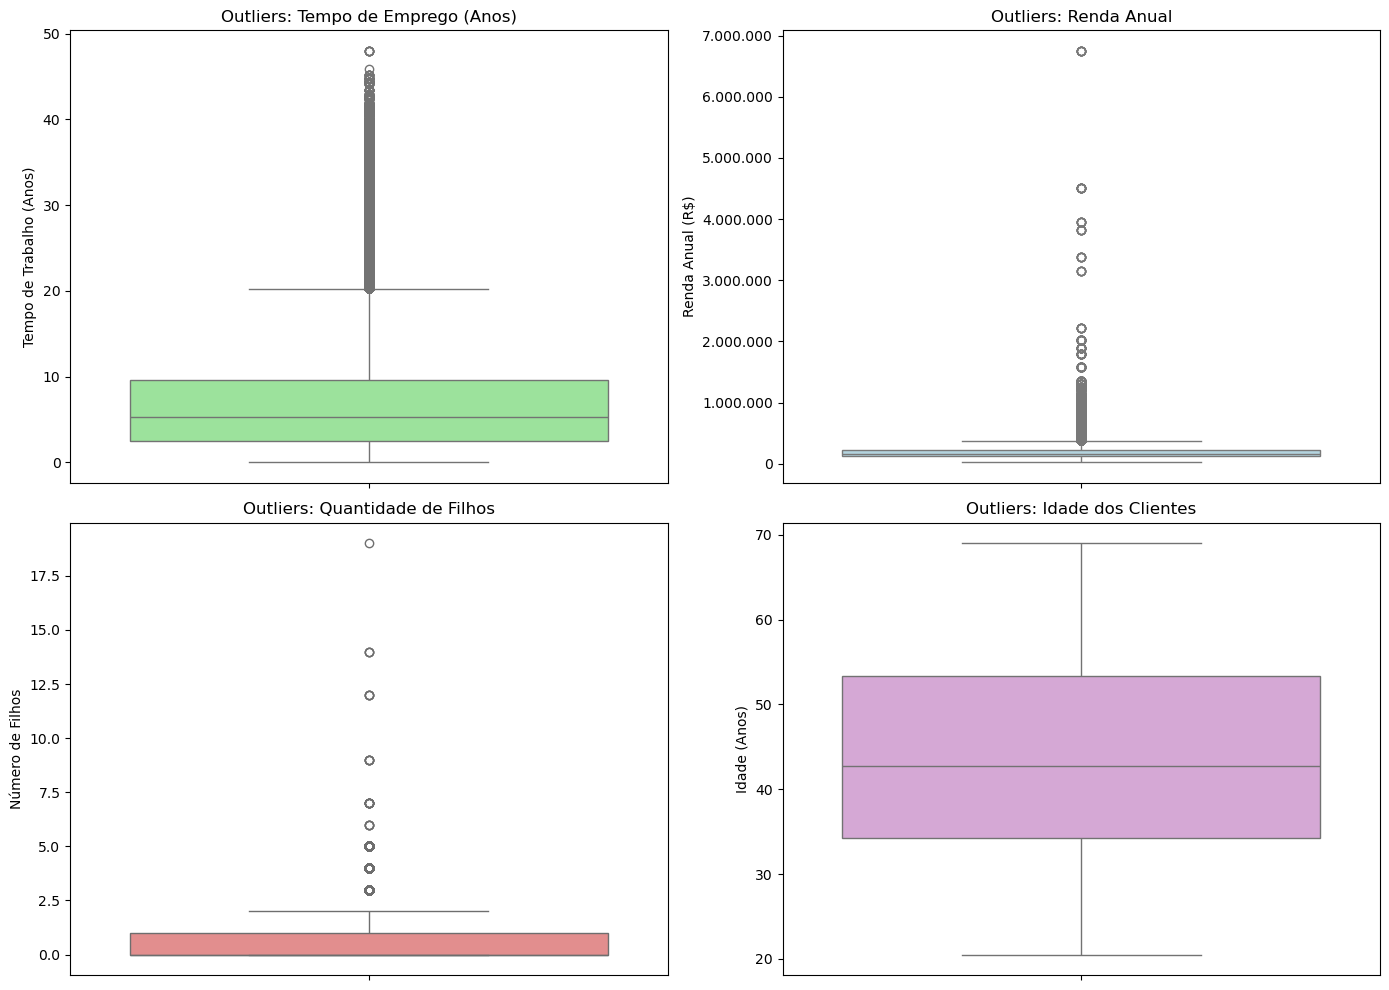

In [10]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

# Criar cópias para ajustes visuais limpos
df_box = df_aplication.copy()

# Filtrar o placeholder de desempregados (365243) para o boxplot de emprego
df_trabalhadores = df_box[df_box['DAYS_EMPLOYED'] != 365243].copy()
df_trabalhadores['ANOS_EMPREGADO'] = -df_trabalhadores['DAYS_EMPLOYED'] / 365.25

df_box['IDADE_ANOS'] = -df_box['DAYS_BIRTH'] / 365.25

# Configurar grid 2x2
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# 1. Boxplot: Tempo de Emprego (Anos positivos)
sns.boxplot(
    y=df_trabalhadores['ANOS_EMPREGADO'], ax=ax[0, 0], color='lightgreen'
)
ax[0, 0].set_title('Outliers: Tempo de Emprego (Anos)')
ax[0, 0].set_ylabel('Tempo de Trabalho (Anos)')

# 2. Boxplot: Renda Anual (Valores reais com padrão brasileiro de formatação: ponto para milhares)
sns.boxplot(y=df_box['AMT_INCOME_TOTAL'], ax=ax[0, 1], color='lightblue')
ax[0, 1].set_title('Outliers: Renda Anual')
ax[0, 1].set_ylabel('Renda Anual (R$)')


# Função para formatar o eixo Y no padrão brasileiro (ex: 1.500.000)
def formato_br(x, pos):
  return f'{x:,.0f}'.replace(',', 'X').replace('.', ',').replace('X', '.')


ax[0, 1].yaxis.set_major_formatter(FuncFormatter(formato_br))

# 3. Boxplot: Quantidade de Filhos
sns.boxplot(y=df_box['CNT_CHILDREN'], ax=ax[1, 0], color='lightcoral')
ax[1, 0].set_title('Outliers: Quantidade de Filhos')
ax[1, 0].set_ylabel('Número de Filhos')

# 4. Boxplot: Idade dos Clientes
sns.boxplot(y=df_box['IDADE_ANOS'], ax=ax[1, 1], color='plum')
ax[1, 1].set_title('Outliers: Idade dos Clientes')
ax[1, 1].set_ylabel('Idade (Anos)')

plt.tight_layout()
plt.show()

**Interpretação:** A análise visual da matriz de *boxplots* (organizada para abranger as principais dimensões demográficas e financeiras do perfil do cliente) revela distribuições, assimetrias e anomalias específicas que exigirão tratamentos direcionados na etapa de pré-processamento:

1. **Tempo de Emprego (`DAYS_EMPLOYED` [dias em que está empregado / tempo de emprego]):** O gráfico foca nos trabalhadores ativos (filtrando o código de sistema). Observa-se que a maioria dos clientes possui entre 0 e 10 anos de vínculo profissional, com *outliers* estatísticos estendendo-se até cerca de 48 anos (refletindo carreiras longas e reais de clientes veteranos). *Nota: O valor de sistema `365.243` (equivalente a ~1.000 anos), que atua como um marcador (*placeholder*) para desempregados ou pensionistas, foi isolado e tratado separadamente.* **Decisão:** Manter a informação estrutural, transformando o *placeholder* no pré-processamento (ex: substituir por 0 e criar uma bandeira binária `IS_UNEMPLOYED`).
2. **Renda Anual (`AMT_INCOME_TOTAL` [renda anual total]):** Apresenta uma forte assimetria à direita, com uma grande concentração nos valores iniciais e diversos *outliers* superiores que chegam a ultrapassar R$ 6.000.000,00. Tratando-se de um portfólio bancário real, clientes de altíssima renda existem e representam um segmento legítimo de alta renda que não deve ser descartado. **Decisão:** Manter os registos, aplicando uma transformação matemática (como o Logaritmo) no pré-processamento para suavizar o peso da cauda direita e evitar distorções no modelo preditivo.
3. **Quantidade de Filhos (`CNT_CHILDREN` [número de filhos]):** Demonstra que a vasta maioria dos clientes possui entre 0 e 2 dependentes, embora o *boxplot* aponte valores extremos atípicos chegando a atingir até 19 filhos. **Decisão:** Aplicar a técnica de *Winsorização* no pré-processamento, estabelecendo um limite máximo (*teto*) estatisticamente consistente para conter o ruído (ex: agrupar valores superiores a 5 em uma única categoria consolidada).
4. **Idade dos Clientes (`DAYS_BIRTH` [dias desde o nascimento / idade]):** Apresenta uma distribuição perfeitamente equilibrada e sem distorções severas, variando dos 20 aos 69 anos, com uma mediana situada em torno dos 43 anos e ausência de valores anômalos. **Decisão:** A variável encontra-se estruturalmente íntegra, exigindo apenas a conversão padrão para anos positivos nas próximas etapas de modelagem.

## 5. Balanceamento de classes
#### Qual a proporção entre as classes e o que isso implica na escolha das métricas?

**Explicação do código:** Embora a consolidação final da variável alvo (`TARGET`) ocorra no próximo notebook de Pré-processamento, podemos analisar o nível de desbalanceamento das classes desde já utilizando a base de histórico (`df_credit`). Vamos aplicar a regra de negócio definida: clientes com atraso igual ou superior a 60 dias (status `2`, `3`, `4`, `5`) são "Maus Pagadores" (1). Agrupamos pelo `ID` do cliente para verificar se ele já foi um mau pagador em algum momento do seu histórico, plotando a proporção de classes num gráfico de barras.

=== Proporção das Classes (Por Cliente) ===
Bons Pagadores (0): 98.55%
Maus Pagadores (1): 1.45%



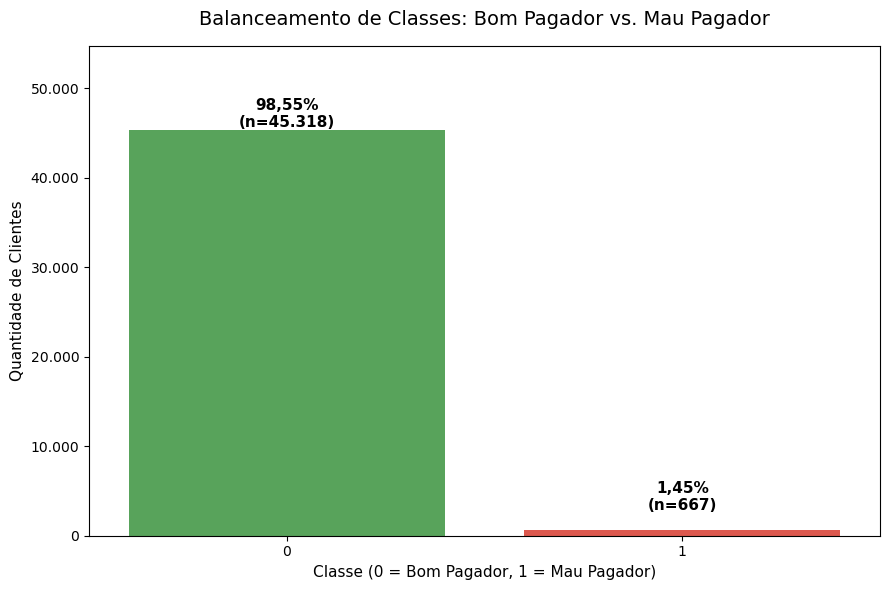

In [11]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

# Mapear a regra de negócio para criar uma variável alvo temporária para a EDA
maus_pagadores_status = ['2', '3', '4', '5']
df_credit['TARGET_TEMP'] = df_credit['STATUS'].apply(
    lambda x: 1 if x in maus_pagadores_status else 0
)

# Agrupar por ID para ver se o cliente teve pelo menos um status de mau pagador no histórico
clientes_alvo = df_credit.groupby('ID')['TARGET_TEMP'].max()

# Calcular a proporção
proporcao = clientes_alvo.value_counts(normalize=True) * 100

print('=== Proporção das Classes (Por Cliente) ===')
print(f'Bons Pagadores (0): {proporcao[0]:.2f}%')
print(f'Maus Pagadores (1): {proporcao[1]:.2f}%\n')

# Gerar Gráfico
plt.figure(figsize=(9, 6))
ax = sns.countplot(
    x=clientes_alvo,
    hue=clientes_alvo,
    palette=['#4CAF50', '#F44336'],
    legend=False,
)
plt.title(
    'Balanceamento de Classes: Bom Pagador vs. Mau Pagador',
    fontsize=14,
    pad=15,
)
plt.xlabel('Classe (0 = Bom Pagador, 1 = Mau Pagador)', fontsize=11)
plt.ylabel('Quantidade de Clientes', fontsize=11)

# Formatar o eixo Y no padrão brasileiro (com ponto para milhares)
formatter = FuncFormatter(
    lambda x, pos: f'{x:,.0f}'
    .replace(',', 'X')
    .replace('.', ',')
    .replace('X', '.')
)
ax.yaxis.set_major_formatter(formatter)

# Adicionar os rótulos de percentagem e contagem exata nas barras para dar clareza
counts = clientes_alvo.value_counts().sort_index()
for p, (val_count, perc) in zip(ax.patches, zip(counts, proporcao)):
  height = p.get_height()
  # Posiciona o texto um pouco acima da barra (ou no topo para barras muito pequenas)
  y_pos = height if height > 2000 else 2500
  ax.annotate(
      f'{perc:.2f}%\n(n={val_count:,.0f})'.replace(',', 'X')
      .replace('.', ',')
      .replace('X', '.'),
      (p.get_x() + p.get_width() / 2., y_pos),
      ha='center',
      va='bottom',
      fontsize=11,
      color='black',
      fontweight='bold',
  )

# Ajustar o limite do eixo Y para dar espaço ao texto da barra menor
plt.ylim(0, ax.get_ylim()[1] * 1.15)

plt.tight_layout()
plt.show()

**Interpretação:** A análise revela um desbalanceamento extremo entre as classes. A imensa maioria dos clientes (mais de 98%) é classificada como "Bons Pagadores", enquanto uma fração mínima atingiu a marca crítica de 60 dias de atraso ("Maus Pagadores")[cite: 11]. Nos rótulos das barras, a notação **`n=`** representa a contagem absoluta (*sample size* ou tamanho da amostra), indicando o número exato de indivíduos inseridos em cada categoria — sendo 45.318 clientes adimplentes e 667 clientes com histórico de inadimplência severa[cite: 11]. 

Este cenário é comum e esperado no mercado de crédito (onde o calote é a exceção), mas traz uma implicação técnica severa para a modelagem: a métrica padrão de "Acurácia" será altamente enganosa. Se um algoritmo preditivo "chutar" que absolutamente todos os clientes pagarão em dia, ele ostentará uma acurácia global próxima de 98%, mas falhará completamente na sua premissa principal, que é identificar o risco de crédito[cite: 11]. Consequentemente, na próxima fase de desenvolvimento, será obrigatório o emprego de técnicas de balanceamento de dados (como *SMOTE* ou *Undersampling*) e a priorização de métricas de avaliação focadas em erros críticos de classificação, tais como o *Recall*, o *F1-Score* ou a área sob a curva *AUC-ROC*[cite: 11].

## 6. Síntese da EDA

A Análise Exploratória de Dados (EDA) validou a qualidade estrutural das bases, revelou *insights* sobre o perfil dos solicitantes e, mais importante, definiu as diretrizes técnicas obrigatórias para a fase de pré-processamento e modelagem:

**1. Perfil Demográfico e Financeiro:** O cliente típico solicitante de crédito encontra-se numa faixa etária ativa (formando um planalto demográfico entre os 27 e 45 anos). A renda apresenta assimetria à direita, concentrando-se nas faixas menores, mas com clientes de alto rendimento reais que não devem ser apagados, exigindo transformações matemáticas (como a aplicação de logaritmo) para estabilizar a variância nos modelos.

**2. Qualidade dos Dados e Redundâncias:** A base exige limpezas pontuais e estratégicas. Identificamos multicolinearidade alta entre a quantidade de filhos e o tamanho da família (indicando a necessidade de remover uma destas colunas), bem como variância zero na posse de celular (100% dos clientes possuem, tornando a variável inútil para diferenciação). Também localizamos um *placeholder* de sistema nos dias empregados (valor isolado de 365.243) que precisará ser tratado como um marcador de "ausência de vínculo empregatício formal".

**3. Estratégia de Modelagem (O Desafio do Desbalanceamento):** A construção da variável alvo, ancorada na regra de provisionamento do Banco Central (PCLD) para atrasos iguais ou superiores a 60 dias, revelou um desbalanceamento severo: **98,55% de Bons Pagadores contra apenas 1,45% de Maus Pagadores.** 
Este achado dita a regra do jogo para a fase de *Machine Learning*: a métrica clássica de "Acurácia" é descartada. O projeto exigirá técnicas de reamostragem (como *SMOTE* ou *Undersampling*) e o modelo será avaliado pela sua capacidade de errar menos no risco sistêmico, priorizando métricas como o *Recall* (capacidade de capturar os maus pagadores reais) e a *AUC-ROC*.